# 05 — Analysis: band recovery, ablation, misspecification

**What you are looking at:** the three questions that decide hypotheses H2
and H3, answered with pre-registered metrics (thresholds were written into
HYPOTHESES.md *before* this analysis ran). Spoiler that the register already
records: all three of this project's pre-registered hypotheses came out
**not supported** — one for a mundane reason (H1: turnover), one informative
(H2: the network learns band-like inertia but not *the* WW band), and one
favorable (H3: the advantage grew on real data instead of shrinking). Every
number is asserted against the frozen artifacts and CLAIMS.md.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

import deep_hedging
from deep_hedging.claims import verify_claims
from deep_hedging.analysis import (
    BAND_COST_LEVELS, BAND_SPOTS, BAND_HOLDINGS, GBM_TEST_DIFF,
    learned_no_trade_region, ww_no_trade_region, band_width,
)
from deep_hedging.policy import load_policy
from deep_hedging.train import TRAIN_SEEDS, weight_path
from deep_hedging.pricing import bs_delta
from deep_hedging.evaluate import CANONICAL, CANONICAL_GBM

ROOT = Path(deep_hedging.__file__).resolve().parents[2]
RESULTS = ROOT / "results"
band = json.loads((RESULTS / "band_analysis.json").read_text())
misspec = json.loads((RESULTS / "misspecification.json").read_text())
ablation = json.loads((RESULTS / "ablation.json").read_text())
lp = json.loads((RESULTS / "learned_policy_results.json").read_text())

## H2 — Did the network rediscover the no-trade band?

**What you are looking at:** the money chart. For a grid of (spot, current
holding) states at the option's mid-life, dark cells are states where the
learned policy holds still (|target − holding| < 0.01 shares). The red
outline is the calibrated Whalley-Wilmott band — where 1990s asymptotic
theory says you should hold still. The pre-registered verdict has two parts:
**overlap** (IoU ≥ 0.5 at every cost level) and **width monotonicity**
(hold region grows with cost, ≥4/5 seeds). Monotonicity passed 5/5; overlap
failed decisively (IoU 0.035–0.137) — the network's hold region is far
narrower than WW's band and sits elsewhere. Verdict: **not supported**; the
network learned band-*like* inertia, not *the* band.

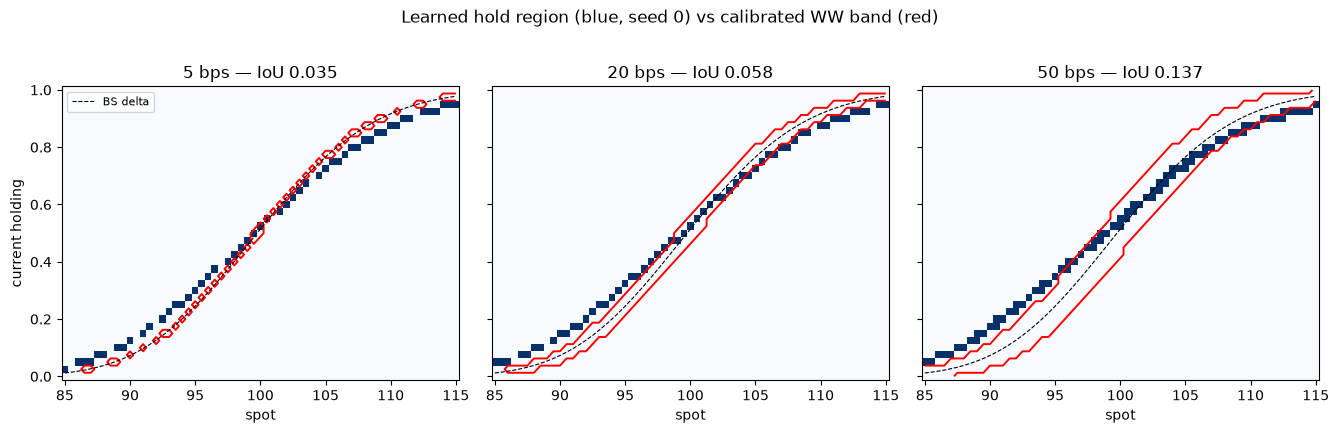

band metrics recompute from committed weights exactly


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for ax, cost in zip(axes, BAND_COST_LEVELS):
    entry = band["per_cost"][str(cost)]
    policy, _ = load_policy(weight_path(cost, 0))
    region = learned_no_trade_region(policy)
    ww = ww_no_trade_region(cost, entry["ww_risk_aversion"])
    ax.pcolormesh(BAND_SPOTS, BAND_HOLDINGS, region.T, cmap="Blues", shading="auto")
    ax.contour(BAND_SPOTS, BAND_HOLDINGS, ww.T, levels=[0.5], colors="red", linewidths=1.4)
    ax.plot(BAND_SPOTS, bs_delta(BAND_SPOTS, CANONICAL["strike"], 0.125, CANONICAL_GBM.sigma),
            "k--", lw=0.8, label="BS delta")
    ax.set_title(f"{cost:g} bps — IoU {entry['iou_mean']:.3f}")
    ax.set_xlabel("spot")
axes[0].set_ylabel("current holding")
axes[0].legend(loc="upper left", fontsize=8)
plt.suptitle("Learned hold region (blue, seed 0) vs calibrated WW band (red)", y=1.02)
plt.tight_layout(); plt.show()

# recompute the shown numbers from weights and assert against the artifact
for cost in BAND_COST_LEVELS:
    entry = band["per_cost"][str(cost)]
    ww = ww_no_trade_region(cost, entry["ww_risk_aversion"])
    policy, _ = load_policy(weight_path(cost, 0))
    region = learned_no_trade_region(policy)
    iou = np.logical_and(region, ww).sum() / np.logical_or(region, ww).sum()
    assert abs(iou - entry["iou_per_seed"][0]) < 1e-9
print("band metrics recompute from committed weights exactly")

## H2 continued — but the *tendency* is real: hold regions widen with cost

**What you are looking at:** the half of H2 that did pass. Each line is one
training seed; the learned hold-region width grows strictly with the cost
level for all 5 seeds (0.021 → 0.023 → 0.033 on across-seed means). The
network discovered *that* you should trade less when trading is expensive —
it just implements that wisdom in a different corner of state space than the
WW asymptotic band.

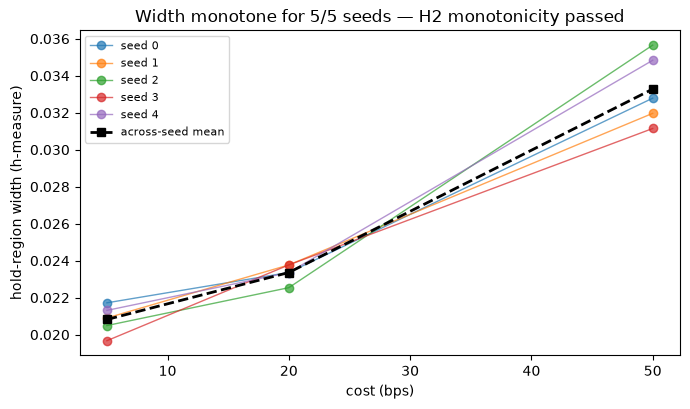

H2: not supported | iou_pass: False | monotone_pass: True


In [3]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for i, seed in enumerate(TRAIN_SEEDS):
    widths = [band["per_cost"][str(c)]["width_per_seed"][i] for c in BAND_COST_LEVELS]
    ax.plot(BAND_COST_LEVELS, widths, "o-", lw=1, alpha=0.7, label=f"seed {seed}")
ax.plot(BAND_COST_LEVELS, [band["per_cost"][str(c)]["width_mean"] for c in BAND_COST_LEVELS],
        "ks--", lw=2, label="across-seed mean")
ax.set_xlabel("cost (bps)"); ax.set_ylabel("hold-region width (h-measure)")
ax.set_title(f"Width monotone for {band['seeds_monotone_count']}/5 seeds — H2 monotonicity passed")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

assert band["seeds_monotone_count"] == 5 and band["means_monotone"]
assert band["h2_verdict"] == "not supported"  # IoU failed; recorded honestly
print("H2:", band["h2_verdict"], "| iou_pass:", band["iou_pass"], "| monotone_pass:", band["monotone_pass"])

## Ablation — was the inventory input load-bearing?

**What you are looking at:** five policies retrained identically except they
cannot see their own current holding (the input that makes "hold still"
behavior expressible). Comparison on the frozen TEST set at 20 bps. The outcome is
the interesting third option: tail risk is statistically unchanged (1.5831 ±
0.0182 vs 1.5781 ± 0.0161 — within seed noise) but the stateless policy
trades ~14% more (3.11 vs 2.74). The inventory input buys **cost
efficiency, not risk reduction** — knowing the current position lets the
policy skip needless trades. This also explains H2: hold-still behavior
matters to the policy for costs, not for the tail.

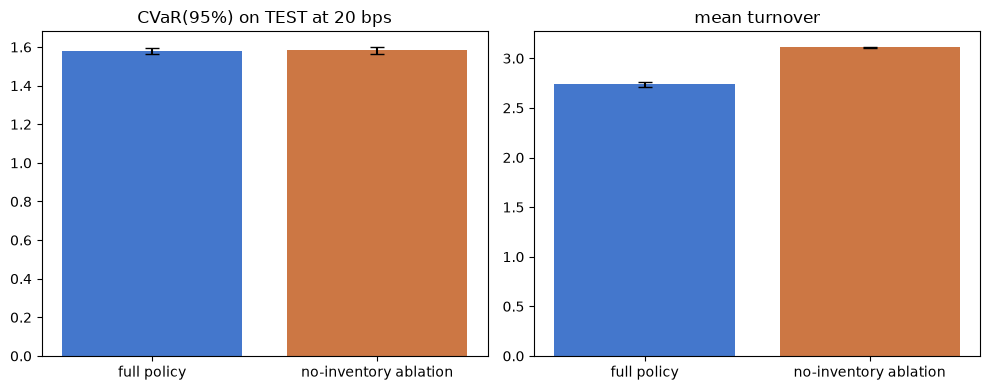

full:      CVaR95 1.5781 ± 0.0161, turnover 2.737
stateless: CVaR95 1.5831 ± 0.0182, turnover 3.110


In [4]:
full = ablation["full_policy_across_seeds"]
abl = ablation["across_seeds"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for ax, key, title in [(ax1, "cvar95", "CVaR(95%) on TEST at 20 bps"),
                       (ax2, "turnover", "mean turnover")]:
    vals = [full[key]["mean"], abl[key]["mean"]]
    errs = [full[key]["std"], abl[key]["std"]]
    ax.bar(["full policy", "no-inventory ablation"], vals, yerr=errs, capsize=5, color=["#47c", "#c74"])
    ax.set_title(title)
plt.tight_layout(); plt.show()

print(f"full:      CVaR95 {full['cvar95']['mean']:.4f} ± {full['cvar95']['std']:.4f}, turnover {full['turnover']['mean']:.3f}")
print(f"stateless: CVaR95 {abl['cvar95']['mean']:.4f} ± {abl['cvar95']['std']:.4f}, turnover {abl['turnover']['mean']:.3f}")

## H3 — What happens off-distribution?

**What you are looking at:** the paired CVaR(95%) difference (learned policy
minus calibrated WW; negative = policy better) with bootstrap CIs, on the
GBM test set the policy was trained for and on four sets it never saw:
Heston stochastic-vol paths and NIFTY block-bootstrap paths at three block
lengths. Pre-registered H3 predicted the advantage would *shrink but not
invert*. Half right: it never inverts (all CIs below zero). But on real
NIFTY data it *widens* — the vol-estimate feature adapts to volatility
clustering while WW's fixed-sigma formula cannot. Verdict: **not
supported**, by a favorable violation. Caveat shown in the error bars:
across-seed spread grows ~15x under distribution shift.

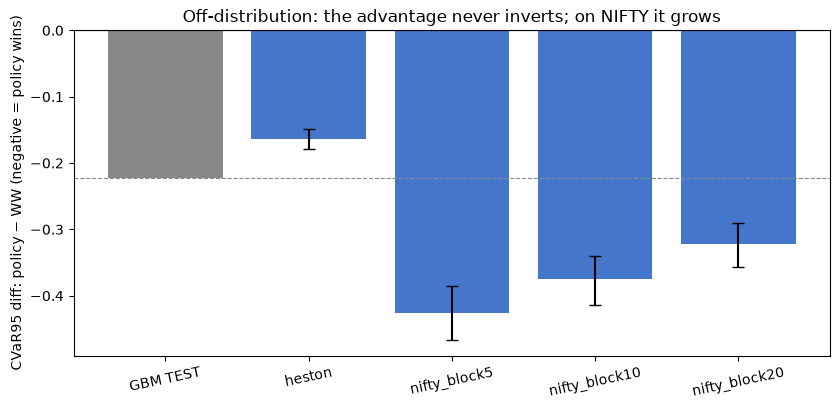

        heston: diff -0.1634 CI [-0.17820629683345632, -0.14916722017911976] | policy 2.280±0.008 vs WW 2.443
  nifty_block5: diff -0.4259 CI [-0.4670862445332814, -0.3852051134170418] | policy 3.006±0.247 vs WW 3.430
 nifty_block10: diff -0.3754 CI [-0.4133864895399301, -0.34080008013593177] | policy 2.827±0.247 vs WW 3.201
 nifty_block20: diff -0.3220 CI [-0.356498641744363, -0.29059768387331913] | policy 2.538±0.248 vs WW 2.858
NIFTY snapshot: 2462 closes 2016-07-15..2026-07-15 sha256 01a2a6fd25f17814…


In [5]:
names = ["GBM TEST", "heston", "nifty_block5", "nifty_block10", "nifty_block20"]
diffs = [GBM_TEST_DIFF] + [misspec["sets"][n]["cvar_diff_mean"] for n in names[1:]]
los = [np.nan] + [misspec["sets"][n]["cvar_diff_mean"] - misspec["sets"][n]["cvar_diff_ci95"][0] for n in names[1:]]
his = [np.nan] + [misspec["sets"][n]["cvar_diff_ci95"][1] - misspec["sets"][n]["cvar_diff_mean"] for n in names[1:]]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(names))
ax.bar(x, diffs, color=["#888"] + ["#47c"] * 4)
ax.errorbar(x[1:], diffs[1:], yerr=[los[1:], his[1:]], fmt="none", ecolor="k", capsize=4)
ax.axhline(0, color="k", lw=0.8)
ax.axhline(GBM_TEST_DIFF, color="#888", lw=0.8, ls="--")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=12)
ax.set_ylabel("CVaR95 diff: policy − WW (negative = policy wins)")
ax.set_title("Off-distribution: the advantage never inverts; on NIFTY it grows")
plt.tight_layout(); plt.show()

for n in names[1:]:
    s = misspec["sets"][n]
    print(f"{n:>14}: diff {s['cvar_diff_mean']:+.4f} CI {s['cvar_diff_ci95']} | policy {s['policy_cvar95_mean']:.3f}±{s['policy_cvar95_std']:.3f} vs WW {s['ww_cvar95']:.3f}")
assert misspec["not_inverted"] and not misspec["shrunk"]
assert misspec["h3_verdict"] == "not supported"
meta = json.loads((ROOT / "data" / "nifty_metadata.json").read_text())
print(f"NIFTY snapshot: {meta['n_observations']} closes {meta['date_range'][0]}..{meta['date_range'][1]} sha256 {meta['sha256'][:16]}…")

## Frozen-claims check

Every number shown above is registered in `CLAIMS.md` and verified here.

In [6]:
computed = {
    f"H2-WIDTH-{c:g}": band["per_cost"][str(c)]["width_mean"] for c in BAND_COST_LEVELS
} | {
    f"H2-IOU-{c:g}": band["per_cost"][str(c)]["iou_mean"] for c in BAND_COST_LEVELS
} | {
    "H3-HESTON-CVAR-DIFF": misspec["sets"]["heston"]["cvar_diff_mean"],
    "H3-NIFTY-CVAR-DIFF": misspec["sets"]["nifty_block10"]["cvar_diff_mean"],
    "ABL20-CVAR95-MEAN": ablation["across_seeds"]["cvar95"]["mean"],
}
print(verify_claims("05_analysis", computed))
print("05_analysis: all assertions passed")

verified 9 claims for 05_analysis (atol=0.0001)
05_analysis: all assertions passed
